In [1]:
#Imports
from utils import DataLoader
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score
import shap

In [2]:
#Load and preprocess data
data_loader = DataLoader()
data_loader.load_dataset()
data_loader.preprocess_data()
# Split the data for evaluation
X_train, X_test, y_train, y_test = data_loader.get_data_split()
# Oversample the train data
X_train, y_train = data_loader.oversample(X_train, y_train)
print(X_train.shape)
print(X_test.shape)

(7778, 21)
(1022, 21)


In [3]:
#Fit blackbox model
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(f"F1 Score {f1_score(y_test, y_pred, average='macro')}")
print(f"Accuracy {accuracy_score(y_test, y_pred)}")

F1 Score 0.5322285353535354
Accuracy 0.9432485322896281


In [4]:
#Create SHAP explainer
explainer = shap.TreeExplainer(rf)
# Calculate shapley values for test data
start_index = 1
end_index = 2
shap_values = explainer.shap_values(X_test[start_index:end_index])
X_test[start_index:end_index]

,gender_Female,gender_Male,gender_Other,ever_married_No,ever_married_Yes,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,age,hypertension,heart_disease,avg_glucose_level,bmi
2813,False,True,False,False,True,False,False,True,False,False,False,True,False,False,True,False,43.0,0,0,91.13,33.9


In [5]:
#Investigating the values (classification problem)
# class 0 = contribution to class 1
# class 1 = contribution to class 2
print(shap_values[0].shape)
shap_values

(21, 2)


array([[[ 8.52901085e-03, -8.52901085e-03],
        [ 8.08595687e-03, -8.08595687e-03],
        [-2.85493601e-07,  2.85493601e-07],
        [-2.99744875e-03,  2.99744875e-03],
        [-4.35650398e-03,  4.35650398e-03],
        [-5.74806210e-04,  5.74806210e-04],
        [-1.54685830e-05,  1.54685830e-05],
        [ 2.53643346e-03, -2.53643346e-03],
        [ 1.20687838e-02, -1.20687838e-02],
        [-2.81922699e-03,  2.81922699e-03],
        [ 7.53255118e-03, -7.53255118e-03],
        [ 7.01882801e-03, -7.01882801e-03],
        [-1.46218322e-03,  1.46218322e-03],
        [ 1.55690952e-02, -1.55690952e-02],
        [ 1.70011011e-02, -1.70011011e-02],
        [ 5.01908244e-03, -5.01908244e-03],
        [ 2.35302467e-01, -2.35302467e-01],
        [ 1.20904393e-02, -1.20904393e-02],
        [ 8.27220000e-03, -8.27220000e-03],
        [ 8.91745702e-02, -8.91745702e-02],
        [ 8.39161213e-02, -8.39161213e-02]]])

The RF predicted: 0


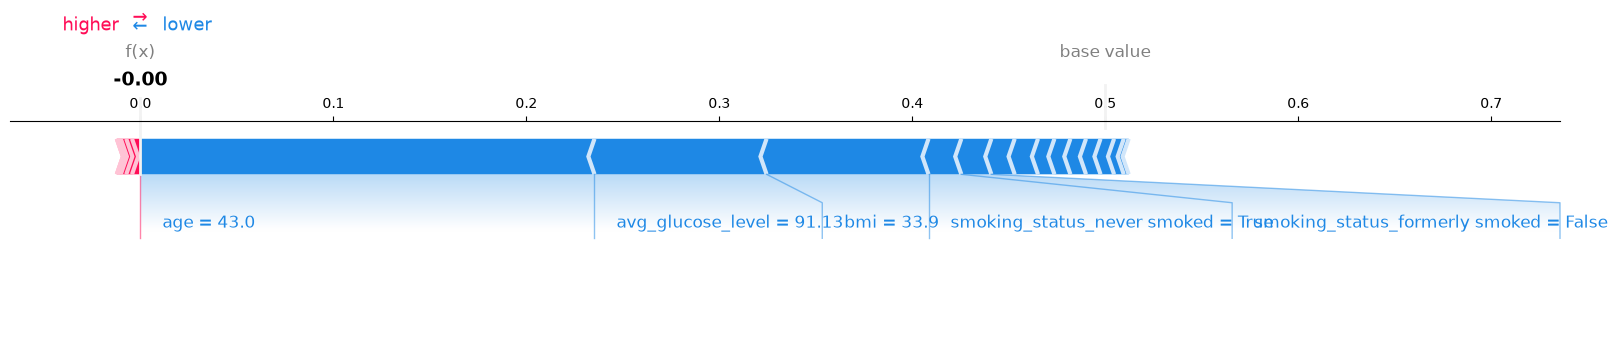

In [17]:
#Visualize local predictions
prediction = rf.predict(X_test[start_index:end_index])[0]
print(f"The RF predicted: {prediction}")

shap.plots.force(
    shap_values[0, :, 1],
    matplotlib=True,
    show=False
)

import matplotlib.pyplot as plt
plt.gcf().set_facecolor("white")
plt.gca().set_facecolor("white")
plt.show()